In [1]:
# Imports etc.
from pathlib import Path

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
# root = Path('/media/yannik/Intenso/DATA/dfg_plexus')
root = Path('F:/DATA/dfg_plexus/')
hc_data = pd.read_csv(root / "Dataset002_DFGFinetuned_3d_fullres_full_new_hc___volumes.csv")
ms_data = pd.read_csv(root / "Dataset002_DFGFinetuned_3d_fullres_full_ms___volumes.csv")

In [3]:
# Extract volumes
volumes_hc = hc_data['volume']
volumes_ms = ms_data['volume']

### Hypothesis Testing
Null Hypothesis: The mean volume of the choroid plexus is the same for healthy controls and pathological (MS) cases. <br>
Alternative Hypothesis: The mean volume of the choroid plexus is different for healthy controls and pathological (MS) cases.

# Statistical significance tests

In [4]:
# Check normality with Shapiro-Wilk test
shapiro_hc = stats.shapiro(volumes_hc)
shapiro_patho = stats.shapiro(volumes_ms)

print("Shapiro-Wilk Test for Normality:")
print(f"HC: W={shapiro_hc.statistic}, p={shapiro_hc.pvalue}")
print(f"MS: W={shapiro_patho.statistic}, p={shapiro_patho.pvalue}")

Shapiro-Wilk Test for Normality:
HC: W=0.9644967560918396, p=0.09261659314814516
MS: W=0.9889478569797245, p=0.0001367088639524062


In [5]:
# Check for homogeneity of variances with Levene's test
levene = stats.levene(volumes_hc, volumes_ms)
print("Levene's Test for Homogeneity of Variances:")
print(f"W={levene.statistic}, p={levene.pvalue}")

Levene's Test for Homogeneity of Variances:
W=0.4454390278109872, p=0.5047386856870664


In [6]:
# Choosing appropriate test based on normality and variance of distributions

if shapiro_hc.pvalue > 0.05 and shapiro_patho.pvalue > 0.05:  # Both normal
    if levene.pvalue > 0.05:  # Equal variances
        test_result = stats.ttest_ind(volumes_hc, volumes_ms)
        test_name = "Two-Sample T-Test"
    else:  # Unequal variances
        test_result = stats.ttest_ind(volumes_hc, volumes_ms, equal_var=False)
        test_name = "Welch's T-Test"
else:  # Non-normal distribution
    test_result = stats.mannwhitneyu(volumes_hc, volumes_ms)
    test_name = "Mann-Whitney U Test"  # (Wilcoxon Rank-Sum Test)

print(f"\n{test_name}:")
print(f"Statistic={test_result.statistic}, p={test_result.pvalue}")


Mann-Whitney U Test:
Statistic=12294.5, p=0.00019012079694451993


In [7]:
# Custom color palette for the two subgroups
custom_palette = {'HC': '#1f77b4', 'MS': '#ff7f0e'}

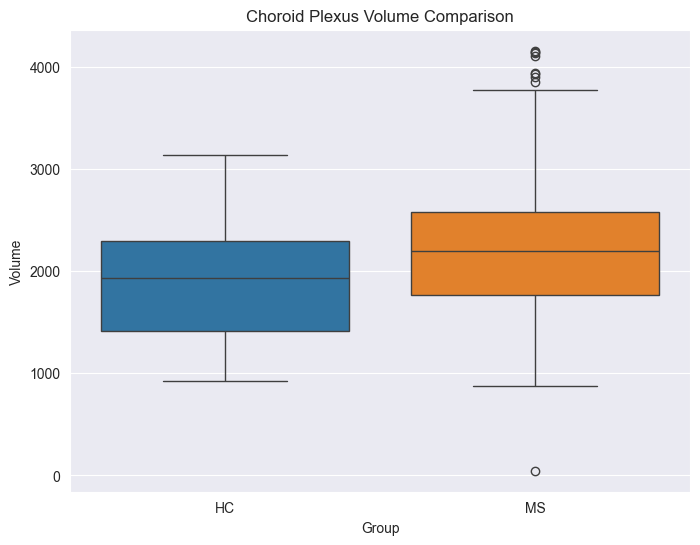

In [8]:
# Visualize the data
combined_volumes = pd.concat([volumes_hc, volumes_ms], axis=0)
group_labels = ['HC'] * len(volumes_hc) + ['MS'] * len(volumes_ms)

visualization_df = pd.DataFrame({'Volume': combined_volumes, 'Group': group_labels})

plt.figure(figsize=(8, 6))
sns.boxplot(data=visualization_df, x='Group', y='Volume', palette=custom_palette, hue='Group')
plt.title("Choroid Plexus Volume Comparison")
plt.ylabel("Volume")
plt.savefig("choroid_plexus_volume_comparison.png")
plt.show()

# Effect size calculation

In [10]:
import numpy as np

# Calculate medians
median_hc = np.median(volumes_hc)
median_patho = np.median(volumes_ms)
median_difference = median_patho - median_hc

print(f"Median of HC group: {median_hc}")
print(f"Median of MS group: {median_patho}")
print(f"Median Difference (Patho - HC): {median_difference}")

Median of HC group: 1928.0
Median of MS group: 2192.999607861042
Median Difference (Patho - HC): 264.999607861042


In [11]:
# Calculate Cliff's Delta
def cliffs_delta(x, y):
    n_x = len(x)
    n_y = len(y)
    pairs = [(xi, yi) for xi in x for yi in y]
    greater = sum(xi > yi for xi, yi in pairs)
    smaller = sum(xi < yi for xi, yi in pairs)
    return (greater - smaller) / (n_x * n_y)

cliffs_delta_value = cliffs_delta(volumes_hc, volumes_ms)
print(f"Cliff's Delta: {cliffs_delta_value:.3f}")

Cliff's Delta: -0.299


In [12]:
# Interpret Cliff's Delta
if abs(cliffs_delta_value) < 0.147:
    interpretation = "negligible"
elif abs(cliffs_delta_value) < 0.33:
    interpretation = "small"
elif abs(cliffs_delta_value) < 0.474:
    interpretation = "medium"
else:
    interpretation = "large"

print(f"Effect size interpretation: {interpretation}")

Effect size interpretation: small


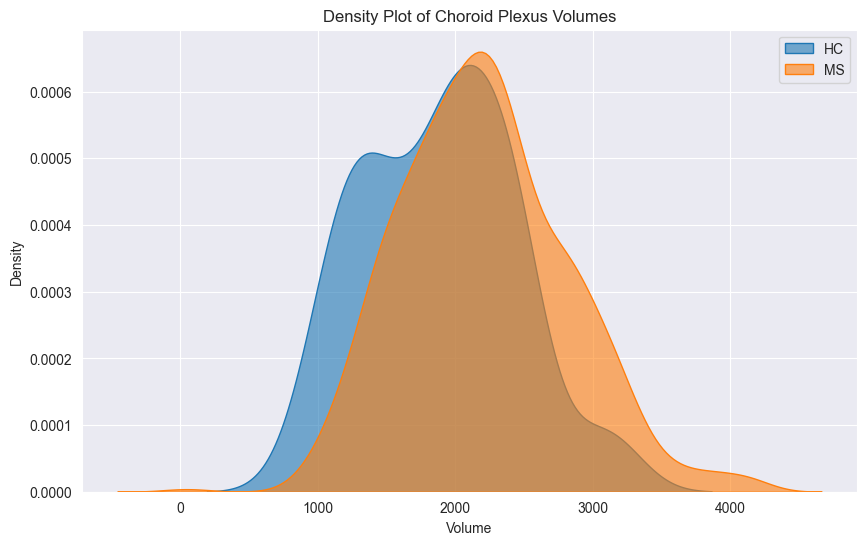

In [13]:
# Visualization

plt.figure(figsize=(10, 6))
sns.kdeplot(volumes_hc, fill=True, label="HC", alpha=0.6, color=custom_palette['HC'])
sns.kdeplot(volumes_ms, fill=True, label="MS", alpha=0.6, color=custom_palette['MS'])
plt.title("Density Plot of Choroid Plexus Volumes")
plt.xlabel("Volume")
plt.ylabel("Density")
plt.legend()
plt.savefig("choroid_plexus_volume_density.png")
plt.show()